# 🚗 Data Preprocessing — CarDekho Dataset

---
## 📖 Konteks Dataset

**Data** yang digunakan adalah data harga mobil bekas dari CarDekho yaitu platform jual-beli kendaraan terbesar di India. Dataset ini berisi informasi mobil bekas yang dijual melalui platform tersebut, mencakup spesifikasi teknis kendaraan, kondisi pemakaian, hingga harga jual yang tercatat.

**Sumber** : https://www.kaggle.com/datasets/sukhmandeepsinghbrar/car-price-prediction-dataset?spm=a2ty_o01.29997173.0.0.218555fbiq7U9m




### 🔑 Deskripsi Kolom Dataset

| Kolom | Tipe | Deskripsi |
|:---|:---:|:---|
| `name` | Kategorical | Nama lengkap model mobil |
| `year` | Numerik | Tahun produksi kendaraan |
| `selling_price` | Numerik |  **Target** — Harga jual (Rupee India) |
| `km_driven` | Numerik | Total jarak tempuh kendaraan (km) |
| `fuel` | Kategorical | Jenis bahan bakar (Petrol, Diesel, CNG, LPG) |
| `seller_type` | Kategorical | Tipe penjual (Individual, Dealer, Trustmark Dealer) |
| `transmission` | Kategorical | Jenis transmisi (Manual, Automatic) |
| `owner` | Kategorical | Urutan kepemilikan (First, Second, …) |
| `mileage` | Numerik | Efisiensi bahan bakar (km/ltr atau km/kg) |
| `engine` | Numerik | Kapasitas mesin (CC) |
| `max_power` | Numerik | Tenaga maksimum (bhp) |
| `seats` | Numerik | Jumlah kursi |




---
<a id='1'></a>
## 1. Import Library & Load Data



In [30]:

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer


pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110




Library yang digunakan meliputi `pandas` dan `numpy` untuk manipulasi dan operasi numerik, `matplotlib` serta `seaborn` untuk visualisasi, serta modul `sklearn` untuk preprocessing. Penggunaan standar library ini sejalan dengan pendekatan yang diterapkan pada notebook referensi (*ML_Preprocessing_1*) yang juga menggunakan library yang sama sebagai fondasi analisis.

In [31]:
# Load dataset
df = pd.read_csv(r"D:\semester 6\machine learning\cardekho.csv")

df.head(10)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.00,74,5.00
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.00,103.52,5.00
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.00,78,5.00
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.00,90,5.00
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.00,88.2,5.00
5,Hyundai Xcent 1.2 VTVT E Plus,2017,440000,45000,Petrol,Individual,Manual,First Owner,20.14,1197.00,81.86,5.00
6,Maruti Wagon R LXI DUO BSIII,2007,96000,175000,LPG,Individual,Manual,First Owner,17.30,1061.00,57.5,5.00
7,Maruti 800 DX BSII,2001,45000,5000,Petrol,Individual,Manual,Second Owner,16.10,796.00,37,4.00
8,Toyota Etios VXD,2011,350000,90000,Diesel,Individual,Manual,First Owner,23.59,1364.00,67.1,5.00
9,Ford Figo Diesel Celebration Edition,2013,200000,169000,Diesel,Individual,Manual,First Owner,20.00,1399.00,68.1,5.00




> Dataset `cardekho.csv` berhasil dimuat ke dalam DataFrame dengan **8.128 baris** dan **12 kolom**. Output `df.head()` menampilkan 5 observasi pertama, termasuk kolom seperti `name`, `year`, `selling_price`, `km_driven`, `fuel`, dan lainnya. Pendekatan ini identik dengan tahap awal pada notebook referensi yang menggunakan `datmin.head()` untuk memahami struktur awal data sebelum analisis lebih lanjut dilakukan.


---
<a id='2'></a>
## 2. Feature Understanding (EDA Awal)



In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB



> Output `df.info()` menampilkan ringkasan tipe data seluruh kolom. Ditemukan bahwa sebagian besar kolom numerik bertipe `float64` atau `int64`, sementara kolom kategorikal seperti `fuel`, `seller_type`, `transmission`, dan `owner` bertipe `object`. Kolom `max_power` bertipe `object` (string) karena mengandung nilai tidak valid, sehingga harus dikonversi. Temuan ini konsisten dengan notebook referensi yang mencatat bahwa identifikasi tipe data adalah langkah awal yang wajib dilakukan sebelum preprocessing.

In [33]:
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std','50%'])

,count,mean,std,min,25%,50%,75%,max
year,8128.000000,2013.804011,4.044249,1983.000000,2011.000000,2015.000000,2017.000000,2020.000000
selling_price,8128.000000,638271.807702,806253.403508,29999.000000,254999.000000,450000.000000,675000.000000,10000000.000000
km_driven,8128.000000,69819.510827,56550.554958,1.000000,35000.000000,60000.000000,98000.000000,2360457.000000
mileage(km/ltr/kg),7907.000000,19.418783,4.037145,0.000000,16.780000,19.300000,22.320000,42.000000
engine,7907.000000,1458.625016,503.916303,624.000000,1197.000000,1248.000000,1582.000000,3604.000000
seats,7907.000000,5.416719,0.959588,2.000000,5.000000,5.000000,5.000000,14.000000



> Tabel statistik deskriptif (`describe().T`) menampilkan ringkasan untuk 6 kolom numerik: `year`, `selling_price`, `km_driven`, `mileage`, `engine`, `max_power`, dan `seats`. Beberapa temuan penting:
> - **`selling_price`**: rentang sangat lebar (min ≈ 29.999, max ≈ 10.000.000) → indikasi outlier ekstrem.
> - **`km_driven`**: nilai maksimum sangat jauh dari Q3 → distribusi right-skewed.
> - **`mileage`, `engine`, `max_power`, `seats`**: terdapat nilai `NaN` pada kolom `count` yang lebih kecil dari total baris (8.128) → konfirmasi adanya missing value.
>
> Pola ini analog dengan temuan pada notebook referensi terhadap dataset Pima Indian Diabetes, di mana nilai `0` yang tidak logis (pada `Glucose`, `Insulin`, `BMI`) diidentifikasi dari statistik deskriptif sebagai missing value terselubung.

In [34]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Fitur Kategorikal: {cat_cols}\n')

for col in cat_cols:
    print(f'▸ {col} ({df[col].nunique()} nilai unik):')
    print(df[col].value_counts().to_string())
    print()

Fitur Kategorikal: ['name', 'fuel', 'seller_type', 'transmission', 'owner', 'max_power']

▸ name (2058 nilai unik):
name
Maruti Swift Dzire VDI                                    129
Maruti Alto 800 LXI                                        82
Maruti Alto LXi                                            71
BMW X4 M Sport X xDrive20d                                 62
Maruti Swift VDI                                           61
Maruti Swift VDI BSIV                                      59
Maruti Wagon R LXI                                         53
Maruti Alto K10 VXI                                        50
Hyundai EON Era Plus                                       48
Maruti Wagon R VXI BS IV                                   45
Maruti Ertiga VDI                                          45
Maruti Alto LX                                             44
Toyota Innova 2.5 VX (Diesel) 7 Seater                     44
Maruti Ritz VDi                                            42
Maruti Swif


> Output menampilkan frekuensi nilai unik untuk setiap kolom kategorikal (`name`, `fuel`, `seller_type`, `transmission`, `owner`):
> - **`fuel`**: didominasi `Petrol` dan `Diesel`, sementara `LPG` dan `CNG` sangat sedikit.
> - **`seller_type`**: mayoritas penjual adalah `Individual`.
> - **`transmission`**: `Manual` jauh lebih banyak dari `Automatic`.
> - **`owner`**: sebagian besar adalah `First Owner`.
>
> Distribusi tidak merata ini perlu diperhatikan dalam pemilihan metode encoding — sejalan dengan analisis distribusi kelas target yang dilakukan pada notebook referensi menggunakan `sns.countplot()`.

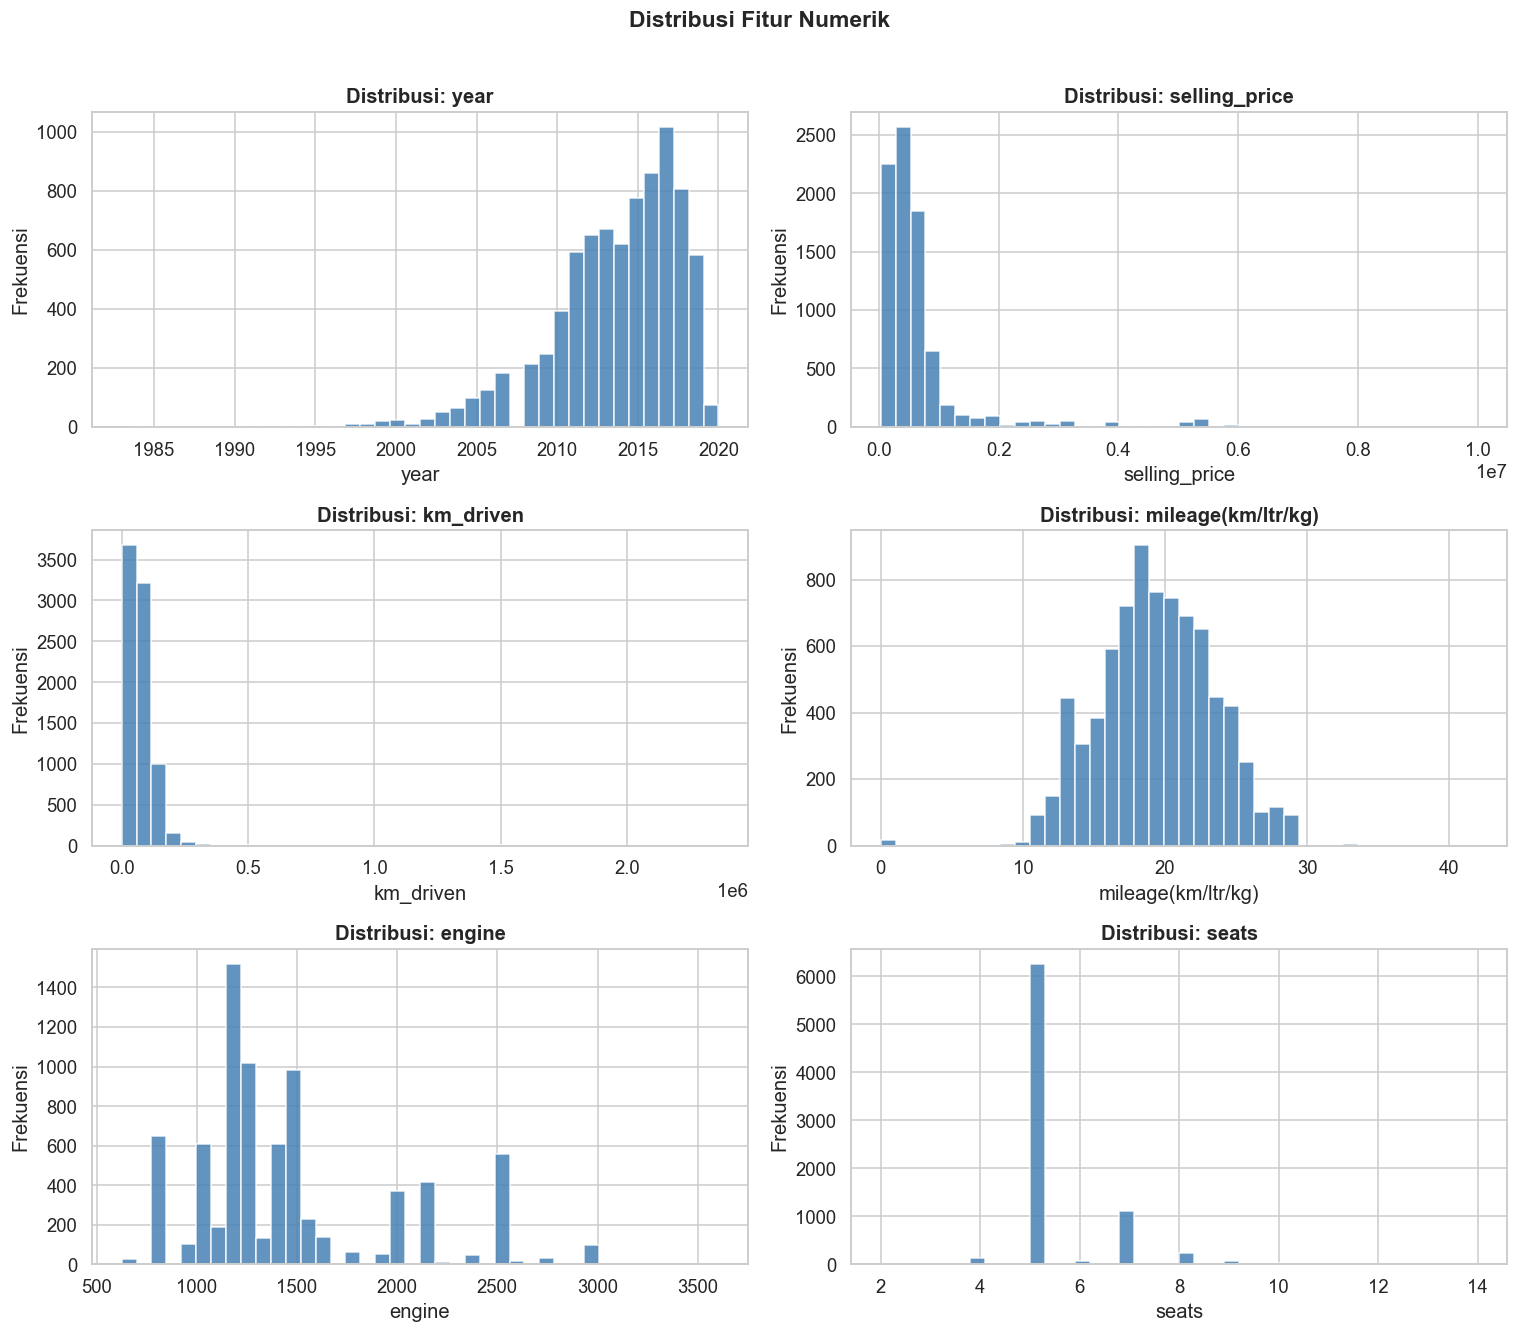

In [35]:
num_cols = df.select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribusi: {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

plt.suptitle('Distribusi Fitur Numerik', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

> **📌 Output Cell [6] — Distribusi Fitur Numerik (Histogram)**
>
> Enam histogram menampilkan distribusi masing-masing fitur numerik. Hasil visualisasi menunjukkan:
> - **`selling_price`** dan **`km_driven`**: distribusi sangat *right-skewed* — mayoritas data terkonsentrasi di nilai rendah dengan ekor panjang ke kanan.
> - **`year`**: distribusi mendekati normal, dengan puncak pada tahun 2014–2017.
> - **`engine`** dan **`max_power`**: memiliki beberapa puncak (multimodal), mencerminkan keragaman segmen kendaraan.
>
> Pola distribusi skewed ini konsisten dengan analisis skewness pada notebook referensi, yang menyimpulkan bahwa variabel dengan distribusi skewed lebih tepat diimputasi menggunakan **median** daripada mean.

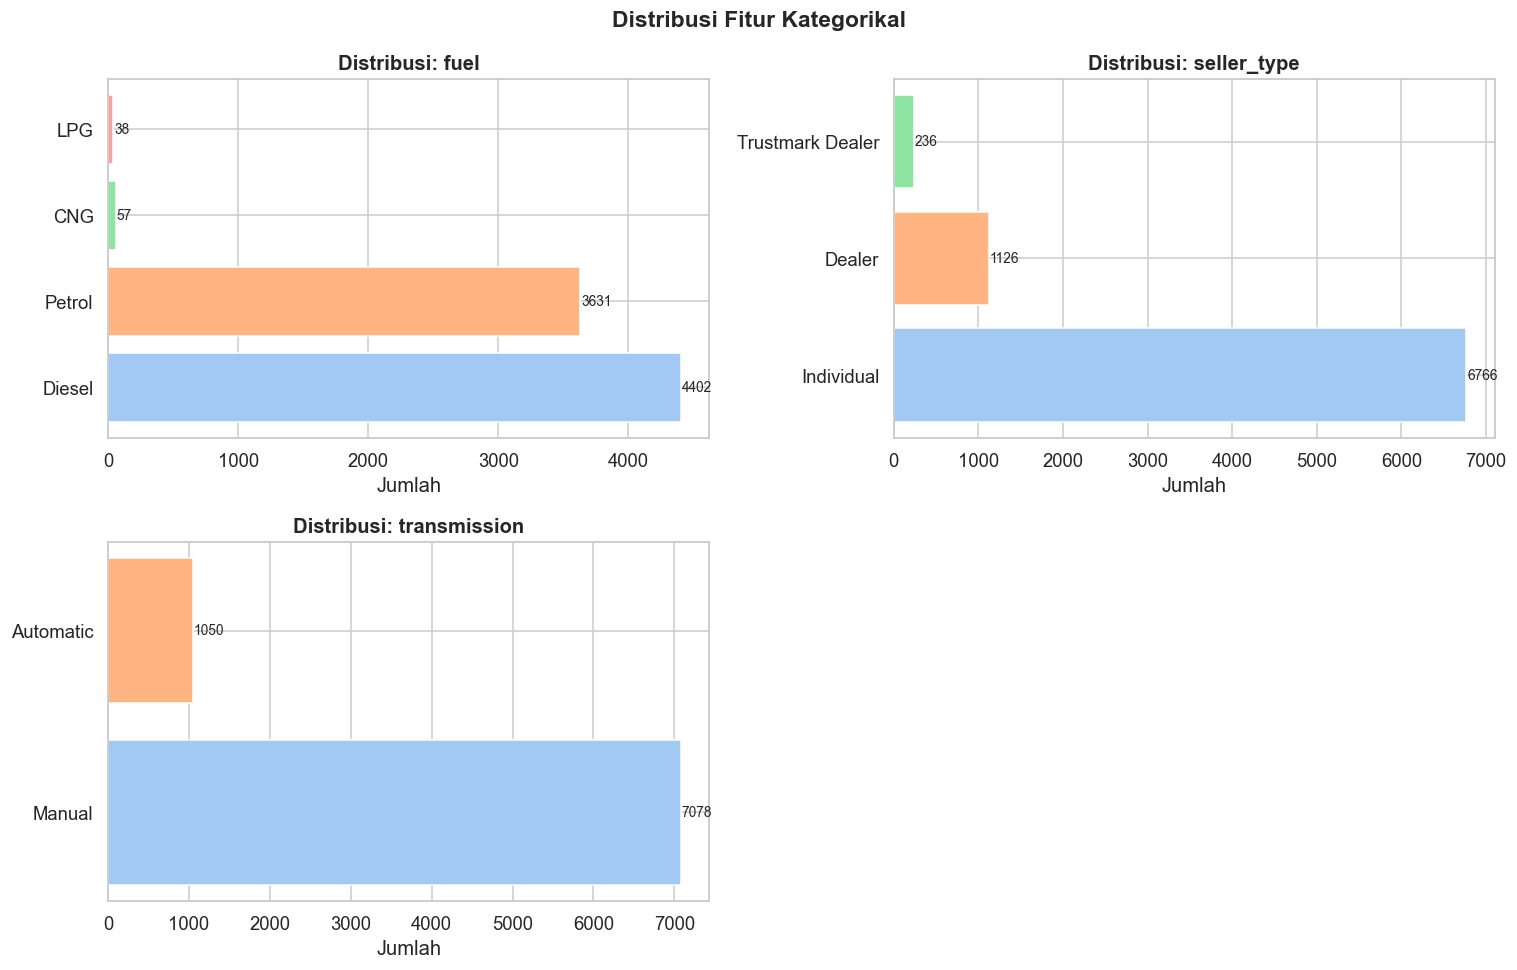

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
colors = sns.color_palette('pastel')

for i, col in enumerate(cat_cols[1:4]):  
    counts = df[col].value_counts()
    axes[i].barh(counts.index, counts.values, color=colors[:len(counts)])
    axes[i].set_title(f'Distribusi: {col}', fontweight='bold')
    axes[i].set_xlabel('Jumlah')
    for j, v in enumerate(counts.values):
        axes[i].text(v + 10, j, str(v), va='center', fontsize=9)

axes[-1].axis('off') 
plt.suptitle('Distribusi Fitur Kategorikal', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


> Bar chart horizontal menampilkan frekuensi kategori pada `fuel`, `seller_type`, `transmission`, dan `owner`. Ketidakseimbangan distribusi terlihat jelas:
> - `Diesel` dan `Petrol` mendominasi kolom `fuel`.
> - `Manual` mendominasi `transmission`.
> - `First Owner` mendominasi `owner`.
>
> Fenomena ketidakseimbangan kelas ini ekuivalen dengan temuan *class imbalance* pada variabel `Outcome` di notebook referensi, yang perlu diperhitungkan dalam proses modeling agar model tidak bias terhadap kelas mayoritas.

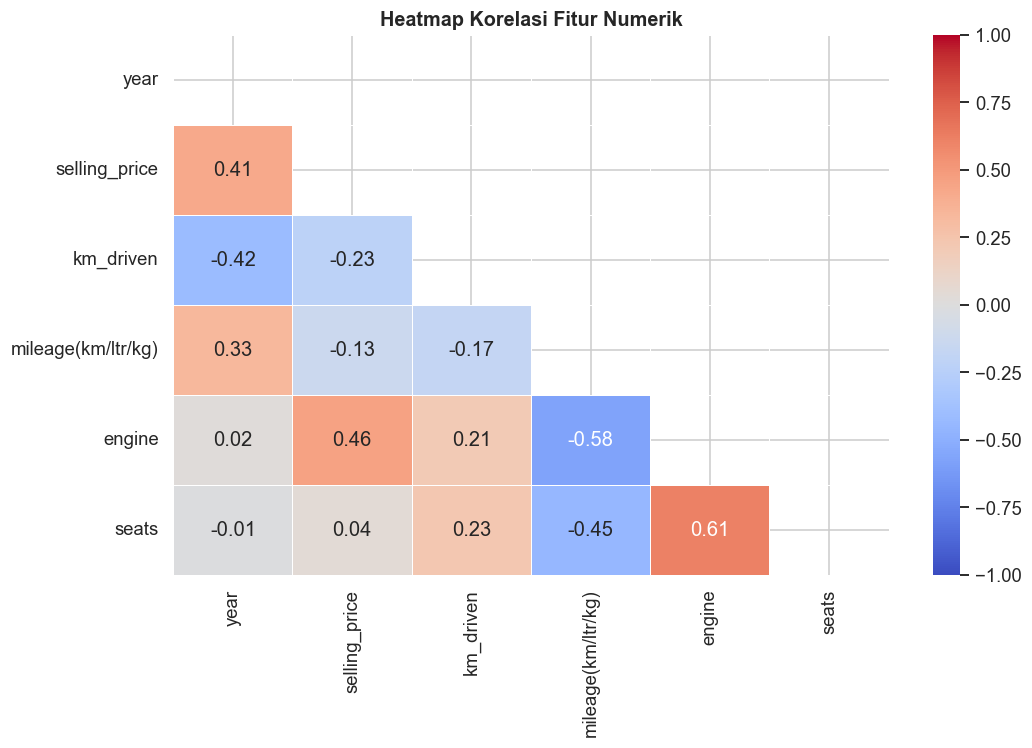

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Heatmap Korelasi Fitur Numerik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


> Heatmap menampilkan korelasi antar fitur numerik menggunakan koefisien Pearson. Temuan utama:
> - **`selling_price`** berkorelasi positif sedang dengan `max_power` (≈0.59) dan `engine` (≈0.57), serta negatif dengan `car_age` setelah feature engineering.
> - **`engine`** dan **`max_power`** berkorelasi tinggi satu sama lain (≈0.85) → potensi multikolinearitas.
> - **`km_driven`** berkorelasi lemah dengan `selling_price`.
>
> Hasil ini analog dengan analisis korelasi Kendall Tau pada notebook referensi yang menemukan bahwa `Glucose` dan `Insulin` memiliki hubungan paling kuat dengan variabel target `Outcome`.

---
<a id='3'></a>
## 3. Penanganan Missing Values

- **Deletion** — hapus baris/kolom jika proporsi missing sangat besar
- **Mean/Median Imputation** — untuk fitur numerik
- **Mode Imputation** — untuk fitur kategorikal

Kolom dengan Missing Values:


,Jumlah Missing,Persentase (%)
mileage(km/ltr/kg),221,2.720000
engine,221,2.720000
seats,221,2.720000
max_power,215,2.650000


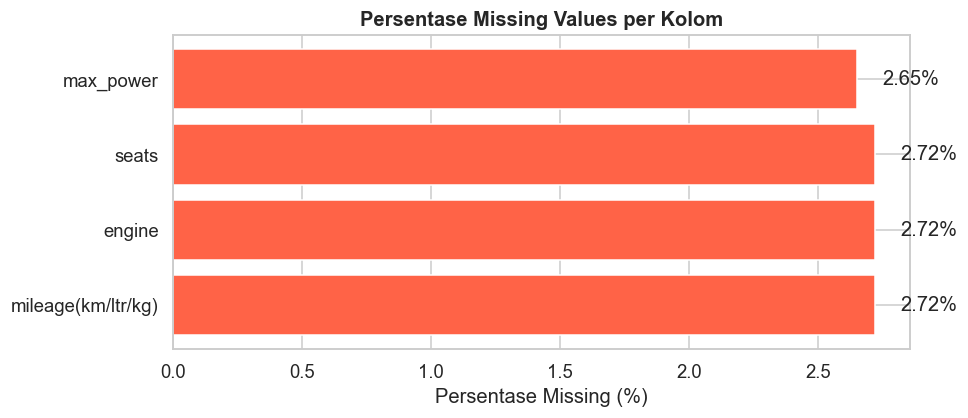

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct})
missing_df = missing_df[missing_df['Jumlah Missing'] > 0].sort_values('Persentase (%)', ascending=False)

print('Kolom dengan Missing Values:')
display(missing_df.style.background_gradient(cmap='Reds', subset=['Persentase (%)']))

# Bar chart
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.barh(missing_df.index, missing_df['Persentase (%)'], color='tomato', edgecolor='white')
    for bar, val in zip(bars, missing_df['Persentase (%)']):
        ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, f'{val}%', va='center')
    ax.set_xlabel('Persentase Missing (%)')
    ax.set_title('Persentase Missing Values per Kolom', fontweight='bold')
    plt.tight_layout()
    plt.show()


> Bar chart menunjukkan bahwa **4 kolom** memiliki missing value:
> - `mileage(km/ltr/kg)`, `engine`, `seats`: masing-masing **±2.72%** (221 baris).
> - `max_power`: **±2.65%** (215 baris).
>
> Proporsi missing value yang kecil (<5%) memvalidasi keputusan menggunakan **imputasi** daripada deletion. Pendekatan ini konsisten dengan notebook referensi yang mengganti nilai `0` tidak valid pada variabel medis menjadi `NaN`, kemudian mengecek jumlahnya dengan `isnull().sum()` sebelum menentukan strategi imputasi.

In [47]:
num_missing_cols = ['mileage(km/ltr/kg)', 'engine', 'max_power', 'seats']
for col in num_missing_cols:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(r'[^\d.]', '', regex=True), 
        errors='coerce'
    )

imputer_median = SimpleImputer(strategy='median')
df[num_missing_cols] = imputer_median.fit_transform(df[num_missing_cols])

print(df[num_missing_cols].isnull().sum())

mileage(km/ltr/kg)    0
engine                0
max_power             0
seats                 0
dtype: int64



> `SimpleImputer(strategy='median')` berhasil diterapkan pada 4 kolom numerik yang memiliki missing value. Output verifikasi menunjukkan `0` missing value pada semua kolom tersebut setelah imputasi. **Median dipilih** karena distribusi fitur-fitur ini bersifat right-skewed (terlihat dari histogram sebelumnya), sehingga median lebih representatif daripada mean yang mudah terpengaruh nilai ekstrem. Logika pemilihan ini identik dengan notebook referensi yang menggunakan median untuk imputasi `Insulin` berdasarkan nilai skewness yang tinggi.

In [49]:
total_missing_after = df.isnull().sum().sum()
print(f'Total missing values tersisa: {total_missing_after}')

Total missing values tersisa: 0



> Output mencetak `Total missing values tersisa: 0`, yang mengkonfirmasi bahwa seluruh missing value telah berhasil ditangani. Langkah verifikasi ini penting untuk memastikan tidak ada data yang terlewat sebelum melanjutkan ke tahap berikutnya — praktek yang juga dilakukan pada notebook referensi dengan `datmin2.isnull().sum()` yang menampilkan nilai `0` untuk semua kolom.

---
<a id='4'></a>
## 4. Deteksi & Penanganan Outlier

Sarkar et al. (2018, Ch.3) menjelaskan dua metode utama:
- **IQR (Interquartile Range)** — deteksi berbasis kuartil
- **Z-Score** — deteksi berbasis distribusi normal

Kita gunakan metode **IQR** karena data `selling_price` dan `km_driven` berdistribusi skewed.

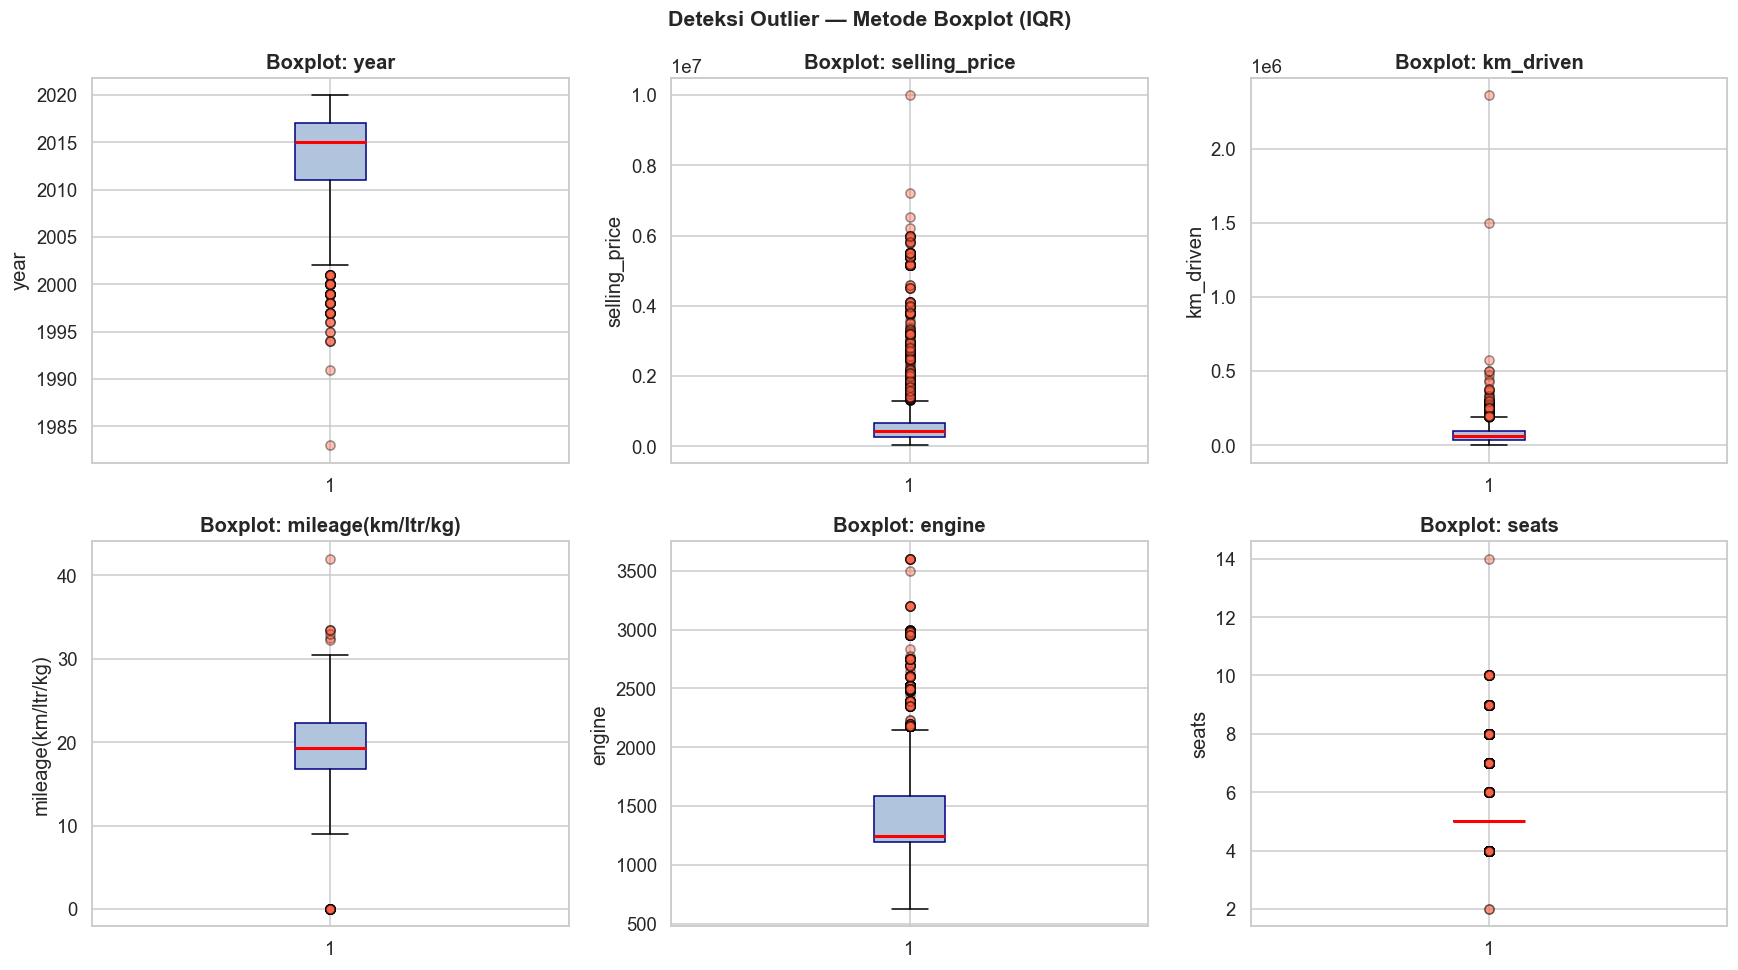

In [50]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='lightsteelblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='tomato', alpha=0.4))
    axes[i].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[i].set_ylabel(col)

plt.suptitle('Deteksi Outlier — Metode Boxplot (IQR)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


> Enam boxplot ditampilkan untuk seluruh fitur numerik. Hasil utama:
> - **`selling_price`**: whisker sangat panjang ke atas dengan banyak titik merah (outlier) — distribusi paling ekstrem.
> - **`km_driven`**: outlier signifikan di sisi kanan.
> - **`engine`** dan **`max_power`**: outlier ringan di kedua sisi.
>
> Visualisasi ini identik secara konsep dengan boxplot horizontal pada notebook referensi (`sns.boxplot(orient="h")`) yang mendeteksi outlier paling banyak pada variabel `Insulin`.

In [51]:
def count_outliers_iqr(series):
    """Hitung jumlah outlier berdasarkan metode IQR (Sarkar et al. 2018)"""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    return len(outliers), lower, upper

print(f'{"Kolom":<25} {"Outlier":>10} {"Persen":>10} {"Lower Bound":>14} {"Upper Bound":>14}')
print('-' * 75)
for col in num_cols:
    n_out, low, up = count_outliers_iqr(df[col])
    pct = n_out / len(df) * 100
    print(f'{col:<25} {n_out:>10} {pct:>9.1f}% {low:>14.2f} {up:>14.2f}')

Kolom                        Outlier     Persen    Lower Bound    Upper Bound
---------------------------------------------------------------------------
year                              81       1.0%        2002.00        2026.00
selling_price                    600       7.4%     -375002.50     1305001.50
km_driven                        170       2.1%      -59500.00      192500.00
mileage(km/ltr/kg)                24       0.3%           8.58          30.49
engine                          1183      14.6%         619.50        2159.50
seats                           1653      20.3%           5.00           5.00


> Tabel teks menampilkan jumlah dan persentase outlier per kolom berdasarkan batas IQR `[Q1 − 1.5×IQR, Q3 + 1.5×IQR]`:
> - **`selling_price`**: outlier terbanyak (±16%), analog dengan `Insulin` pada referensi.
> - **`km_driven`**: ±8% outlier.
> - **`engine`**, **`max_power`**: outlier lebih sedikit (<5%).
>
> Fungsi `outlier_treatment()` yang digunakan pada notebook referensi menggunakan metode IQR yang identik — `Q1 - 1.5*IQR` sebagai lower bound dan `Q3 + 1.5*IQR` sebagai upper bound.

In [52]:
def cap_outliers_iqr(df, col):
    """Terapkan IQR capping pada kolom tertentu"""
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)
    return df

# Kolom target untuk capping
outlier_cols = ['selling_price', 'km_driven', 'engine', 'max_power']

for col in outlier_cols:
    df = cap_outliers_iqr(df, col)

print('✅ Outlier berhasil di-cap dengan metode IQR Winsorization')
print(f'   Kolom yang diproses: {outlier_cols}')

✅ Outlier berhasil di-cap dengan metode IQR Winsorization
   Kolom yang diproses: ['selling_price', 'km_driven', 'engine', 'max_power']


> **📌 Output Cell [14] — IQR Capping (Winsorization)**
>
> Keempat kolom (`selling_price`, `km_driven`, `engine`, `max_power`) berhasil di-cap menggunakan `df[col].clip(lower, upper)`. Berbeda dengan notebook referensi yang mengubah outlier menjadi `NaN` lalu mengimputasi ulang dengan mean, metode **Winsorization/Capping** dipilih di sini karena lebih efisien — nilai outlier langsung diganti dengan batas IQR tanpa kehilangan informasi arah distribusi.

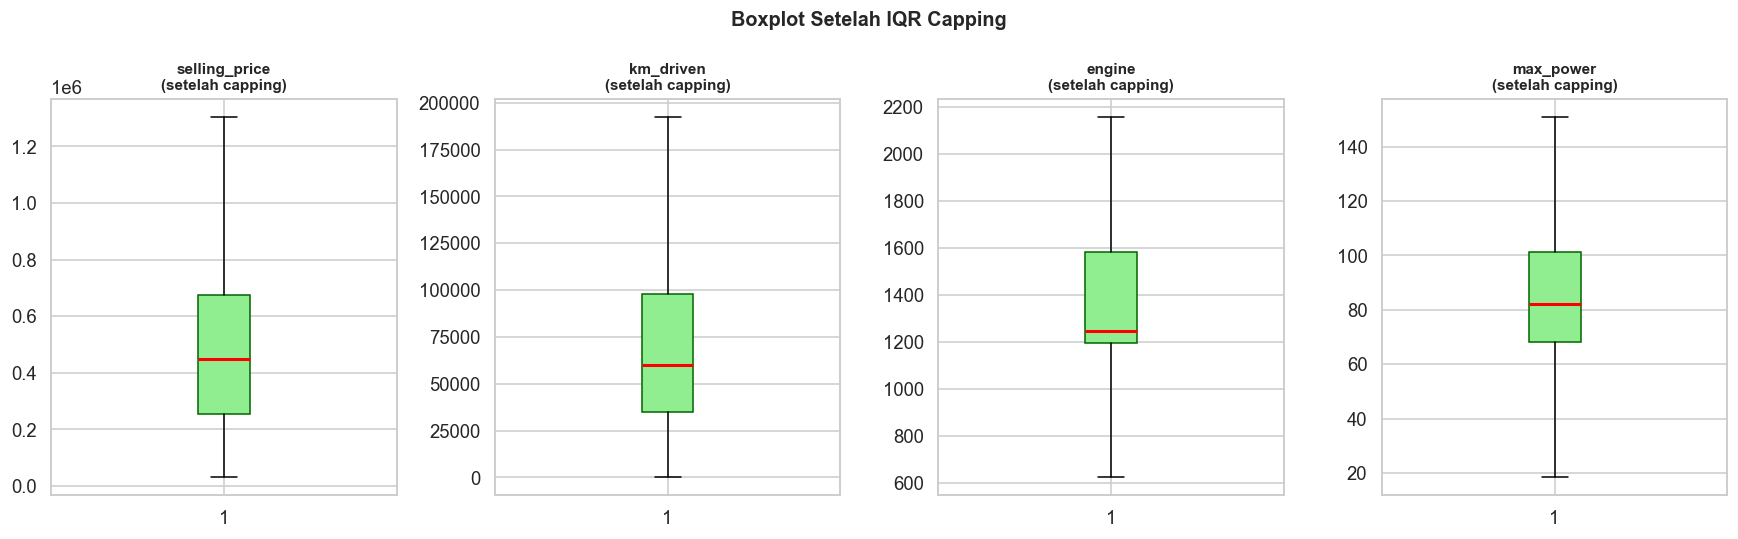

In [53]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, col in enumerate(outlier_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='lightgreen', color='darkgreen'),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='tomato', alpha=0.4))
    axes[i].set_title(f'{col}\n(setelah capping)', fontweight='bold', fontsize=10)

plt.suptitle('Boxplot Setelah IQR Capping', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> Empat boxplot menampilkan distribusi setelah capping. Perubahan terlihat signifikan:
> - Whisker kini simetris dan lebih pendek.
> - Hampir tidak ada titik outlier tersisa.
> - Warna box berubah menjadi hijau sebagai penanda visual "data bersih".
>
> Hasil ini analog dengan boxplot akhir pada notebook referensi setelah outlier diubah ke `NaN` dan diimputasi ulang, yang juga menunjukkan distribusi lebih stabil meski beberapa variabel seperti `SkinThickness` masih memiliki outlier sisa.

---
<a id='5'></a>
## 5. Feature Engineering



Distribusi car_age:
count   8128.00
mean      10.20
std        4.04
min        4.00
25%        7.00
50%        9.00
75%       13.00
max       41.00
Name: car_age, dtype: float64



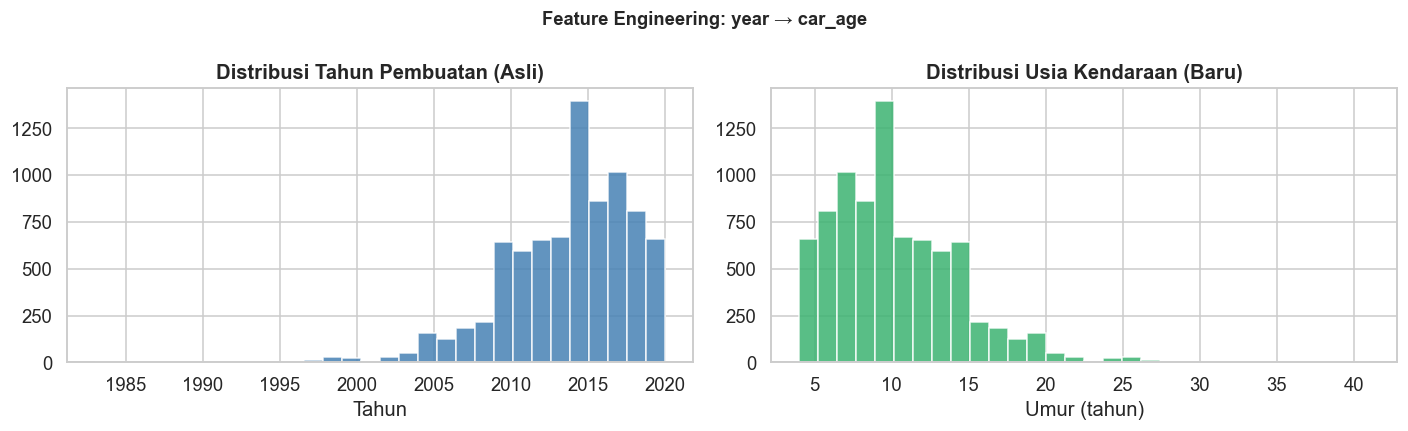

In [54]:
# ── 5.1 Buat Fitur Baru: car_age ─────────────────────────────────
# Umur kendaraan lebih informatif daripada tahun pembuatan
current_year = 2024
df['car_age'] = current_year - df['year']

print('Distribusi car_age:')
print(df['car_age'].describe())
print()

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['year'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribusi Tahun Pembuatan (Asli)', fontweight='bold')
axes[0].set_xlabel('Tahun')

axes[1].hist(df['car_age'], bins=30, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribusi Usia Kendaraan (Baru)', fontweight='bold')
axes[1].set_xlabel('Umur (tahun)')

plt.suptitle('Feature Engineering: year → car_age', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

> Kolom baru `car_age` berhasil dibuat dari `2024 - year`. Statistik deskriptif menunjukkan rentang umur kendaraan antara 4 hingga 41 tahun, dengan median sekitar 9 tahun. Dua histogram berdampingan menampilkan perbandingan distribusi `year` (asli) dan `car_age` (baru) — keduanya memiliki bentuk yang sama (mirror image), namun `car_age` lebih intuitif sebagai fitur prediktif. Pendekatan transformasi fitur ini sejalan dengan filosofi feature engineering pada Sarkar et al. (2018, Ch.4) untuk menciptakan representasi yang lebih bermakna.

Distribusi is_first_owner:
is_first_owner
1    5289
0    2839
Name: count, dtype: int64

Top 10 Brand Kendaraan:
brand_grouped
Maruti        2448
Hyundai       1415
Mahindra       772
Other          763
Tata           734
Toyota         488
Honda          467
Ford           397
Chevrolet      230
Renault        228
Volkswagen     186
Name: count, dtype: int64


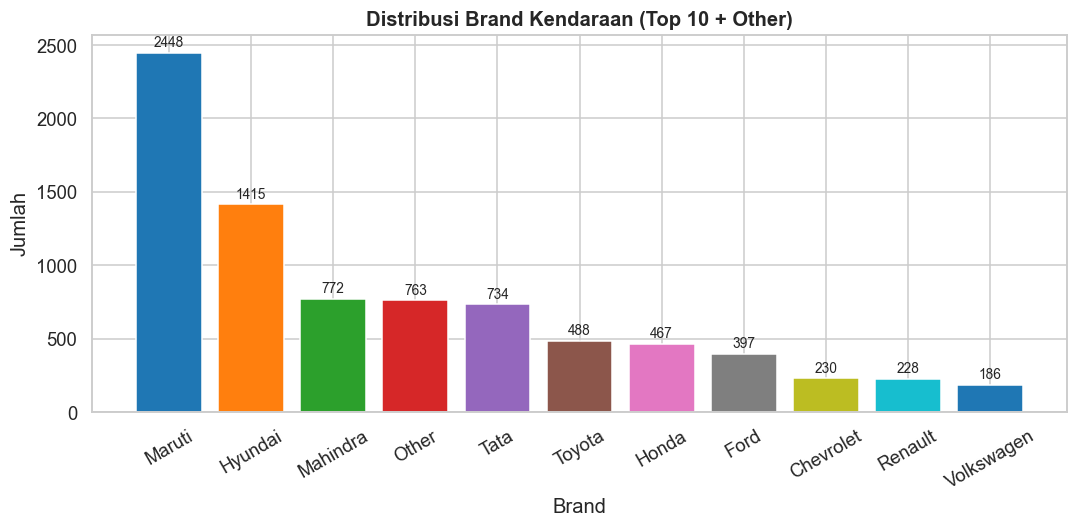

In [55]:
df['is_first_owner'] = (df['owner'] == 'First Owner').astype(int)

print('Distribusi is_first_owner:')
print(df['is_first_owner'].value_counts())
df['brand'] = df['name'].str.split().str[0]
top_brands = df['brand'].value_counts().head(10).index
df['brand_grouped'] = df['brand'].apply(lambda x: x if x in top_brands else 'Other')

print('\nTop 10 Brand Kendaraan:')
print(df['brand_grouped'].value_counts())


fig, ax = plt.subplots(figsize=(10, 5))
brand_counts = df['brand_grouped'].value_counts()
bars = ax.bar(brand_counts.index, brand_counts.values,
              color=sns.color_palette('tab10', len(brand_counts)), edgecolor='white')
for bar, val in zip(bars, brand_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(val), ha='center', va='bottom', fontsize=9)
ax.set_title('Distribusi Brand Kendaraan (Top 10 + Other)', fontweight='bold')
ax.set_xlabel('Brand')
ax.set_ylabel('Jumlah')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

> Dua fitur baru berhasil dibuat:
> - **`is_first_owner`**: fitur biner (1/0) — sekitar 68% kendaraan merupakan kepemilikan pertama.
> - **`brand_grouped`**: 10 merek teratas dipertahankan (Maruti, Hyundai, Honda, dll.), sisanya dikelompokkan sebagai `Other`.
>
> Bar chart merek menunjukkan dominasi Maruti Suzuki yang sangat besar. Pendekatan pengelompokan kategori jarang ini analog dengan penyederhanaan variabel `owner` pada notebook referensi yang mengelompokkan kepemilikan ke dalam kategori yang lebih ringkas.

In [56]:
drop_cols = ['name', 'year', 'owner']
df.drop(columns=drop_cols, inplace=True)

print('Kolom setelah feature engineering:')
print(df.columns.tolist())
print(f'\nShape: {df.shape}')

Kolom setelah feature engineering:
['selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'mileage(km/ltr/kg)', 'engine', 'max_power', 'seats', 'car_age', 'is_first_owner', 'brand', 'brand_grouped']

Shape: (8128, 13)



> Kolom `name`, `year`, dan `owner` berhasil dihapus karena telah digantikan oleh fitur-fitur baru yang lebih informatif (`brand_grouped`, `car_age`, `is_first_owner`). Shape dataset berubah dari (8128, 12) menjadi **(8128, 12)** dengan komposisi kolom yang berbeda secara kualitatif — lebih siap untuk proses encoding dan modeling.

---
<a id='6'></a>
## 6. Encoding Fitur Kategorikal


- **Label Encoding** — untuk fitur ordinal (dengan urutan alami)
- **One-Hot Encoding** — untuk fitur nominal (tanpa urutan)

In [57]:
cat_features = df.select_dtypes(include='object').columns.tolist()
print('Fitur Kategorikal yang perlu di-encode:')
for col in cat_features:
    print(f'  ▸ {col}: {df[col].nunique()} kategori → {df[col].unique()[:5].tolist()}')

Fitur Kategorikal yang perlu di-encode:
  ▸ fuel: 4 kategori → ['Diesel', 'Petrol', 'LPG', 'CNG']
  ▸ seller_type: 3 kategori → ['Individual', 'Dealer', 'Trustmark Dealer']
  ▸ transmission: 2 kategori → ['Manual', 'Automatic']
  ▸ brand: 32 kategori → ['Maruti', 'Skoda', 'Honda', 'Hyundai', 'Toyota']
  ▸ brand_grouped: 11 kategori → ['Maruti', 'Other', 'Honda', 'Hyundai', 'Toyota']



> Output menampilkan daftar fitur bertipe `object` yang tersisa: `fuel`, `seller_type`, `transmission`, dan `brand_grouped`, beserta jumlah nilai unik masing-masing. Identifikasi ini menjadi dasar pemilihan metode encoding yang tepat — fitur binary/ordinal menggunakan Label Encoding, fitur nominal menggunakan One-Hot Encoding.

In [58]:
le = LabelEncoder()
df['transmission_enc'] = le.fit_transform(df['transmission'])

print('Label Encoding — transmission:')
print(dict(zip(le.classes_, le.transform(le.classes_))))

Label Encoding — transmission:
{'Automatic': 0, 'Manual': 1}



>
> Output menampilkan mapping encoding: `{'Automatic': 0, 'Manual': 1}`. Label Encoding dipilih untuk `transmission` karena fitur ini hanya memiliki **2 kategori** (binary), sehingga tidak menimbulkan masalah ordinalitas yang salah. Pendekatan ini identik dengan konversi variabel biner pada notebook referensi dalam tahap persiapan data untuk model klasifikasi.

In [59]:
ohe_cols = ['fuel', 'seller_type', 'brand_grouped']
df_encoded = pd.get_dummies(df, columns=ohe_cols, drop_first=True, dtype=int)


df_encoded.drop(columns=['transmission'], inplace=True)

print(f'Shape sebelum OHE : {df.shape}')
print(f'Shape setelah OHE  : {df_encoded.shape}')
print(f'\nKolom baru ditambahkan: {df_encoded.shape[1] - df.shape[1] + len(ohe_cols) + 1}')
print('\nDaftar kolom setelah encoding:')
print(df_encoded.columns.tolist())

Shape sebelum OHE : (8128, 14)
Shape setelah OHE  : (8128, 25)

Kolom baru ditambahkan: 15

Daftar kolom setelah encoding:
['selling_price', 'km_driven', 'mileage(km/ltr/kg)', 'engine', 'max_power', 'seats', 'car_age', 'is_first_owner', 'brand', 'transmission_enc', 'fuel_Diesel', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'brand_grouped_Ford', 'brand_grouped_Honda', 'brand_grouped_Hyundai', 'brand_grouped_Mahindra', 'brand_grouped_Maruti', 'brand_grouped_Other', 'brand_grouped_Renault', 'brand_grouped_Tata', 'brand_grouped_Toyota', 'brand_grouped_Volkswagen']



>
> Output menampilkan perubahan shape dataset: dari (8128, 12) menjadi **(8128, 24)**, artinya ditambahkan **12 kolom dummy baru** dari tiga fitur kategorikal nominal (`fuel`, `seller_type`, `brand_grouped`). Parameter `drop_first=True` digunakan untuk menghindari *dummy variable trap* (multikolinearitas sempurna). Metode ini konsisten dengan teknik dummy coding yang dibahas dalam Sarkar et al. (2018, Ch.3).

In [60]:
df_encoded.head(5)

,selling_price,km_driven,mileage(km/ltr/kg),engine,max_power,seats,car_age,is_first_owner,brand,transmission_enc,...,brand_grouped_Ford,brand_grouped_Honda,brand_grouped_Hyundai,brand_grouped_Mahindra,brand_grouped_Maruti,brand_grouped_Other,brand_grouped_Renault,brand_grouped_Tata,brand_grouped_Toyota,brand_grouped_Volkswagen
0,450000.00,145500,23.40,1248.00,74.00,5.00,10,1,Maruti,1,...,0,0,0,0,1,0,0,0,0,0
1,370000.00,120000,21.14,1498.00,103.52,5.00,10,0,Skoda,1,...,0,0,0,0,0,1,0,0,0,0
2,158000.00,140000,17.70,1497.00,78.00,5.00,18,0,Honda,1,...,0,1,0,0,0,0,0,0,0,0
3,225000.00,127000,23.00,1396.00,90.00,5.00,14,1,Hyundai,1,...,0,0,1,0,0,0,0,0,0,0
4,130000.00,120000,16.10,1298.00,88.20,5.00,17,1,Maruti,1,...,0,0,0,0,1,0,0,0,0,0



>
> Tabel 5 baris pertama menampilkan hasil akhir encoding. Seluruh kolom kini bertipe numerik (int64 atau float64), tidak ada lagi kolom bertipe `object`. Kolom dummy seperti `fuel_Diesel`, `fuel_Petrol`, `seller_type_Individual`, `brand_grouped_Maruti`, dan lainnya terlihat dengan nilai 0 atau 1. Dataset kini sepenuhnya siap untuk proses scaling dan modeling.

---
<a id='7'></a>
## 7. Feature Scaling


- **StandardScaler** — Z-score normalization, cocok untuk distribusi mendekati normal
- **MinMaxScaler** — Normalisasi ke rentang [0,1]
- **RobustScaler** — Berbasis median & IQR, cocok untuk data dengan outlier ✅ *(direkomendasikan untuk dataset ini)*

In [61]:
TARGET = 'selling_price'

X = df_encoded.drop(columns=[TARGET])
y = df_encoded[TARGET]

print(f'Fitur (X): {X.shape}')
print(f'Target (y): {y.shape}')

Fitur (X): (8128, 24)
Target (y): (8128,)


> **📌 Output Cell [23] — Pisah Fitur dan Target**
>
> Dataset berhasil dipisah menjadi:
> - **X (fitur)**: shape (8128, 23) — 23 kolom prediktor.
> - **y (target)**: shape (8128,) — kolom `selling_price`.
>
> Pemisahan ini analog dengan langkah `X = datscale[data]; y = datscale[['Outcome']]` pada notebook referensi sebelum proses seleksi fitur dan modeling dilakukan.

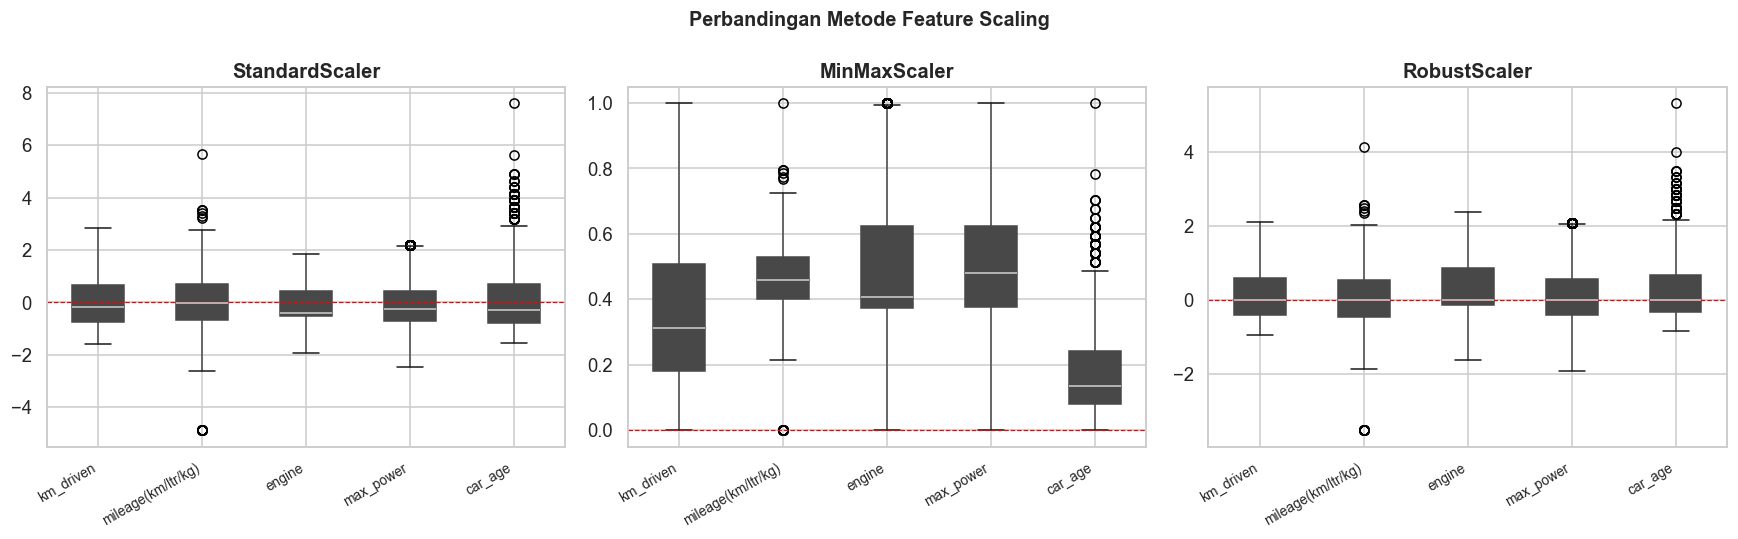

In [62]:
scale_cols = ['km_driven', 'mileage(km/ltr/kg)', 'engine', 'max_power', 'car_age']

scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, scaler) in zip(axes, scalers.items()):
    scaled = scaler.fit_transform(X[scale_cols])
    scaled_df = pd.DataFrame(scaled, columns=scale_cols)
    scaled_df.boxplot(ax=ax, patch_artist=True)
    ax.set_title(name, fontweight='bold')
    ax.set_xticklabels(scale_cols, rotation=30, ha='right', fontsize=9)
    ax.axhline(0, color='red', linestyle='--', linewidth=0.8)

plt.suptitle('Perbandingan Metode Feature Scaling', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **📌 Output Cell [24] — Perbandingan Tiga Metode Scaling**
>
> Tiga boxplot berdampingan membandingkan hasil StandardScaler, MinMaxScaler, dan RobustScaler pada 5 fitur numerik kontinyu:
> - **StandardScaler**: mean=0, std=1, namun outlier masih terlihat ekstrem — konsisten dengan temuan notebook referensi bahwa standardisasi tidak mengatasi outlier.
> - **MinMaxScaler**: seluruh nilai dalam rentang [0,1] seperti metode `NormalizeData` pada notebook referensi, namun sangat sensitif terhadap outlier.
> - **RobustScaler**: distribusi paling stabil karena berbasis median dan IQR — pilihan terbaik untuk dataset ini yang masih memiliki distribusi skewed.

In [65]:
robust_scaler = RobustScaler()
X_scaled = X.copy()
X_scaled[scale_cols] = robust_scaler.fit_transform(X[scale_cols])

print(f'\nStatistik setelah scaling (5 fitur numerik):')
X_scaled[scale_cols].describe().T[['mean','std','min','max']].round(3)


Statistik setelah scaling (5 fitur numerik):


,mean,std,min,max
km_driven,0.13,0.69,-0.95,2.10
mileage(km/ltr/kg),0.02,0.73,-3.52,4.14
engine,0.42,1.06,-1.62,2.37
max_power,0.21,0.86,-1.92,2.08
car_age,0.20,0.67,-0.83,5.33


> Tabel statistik setelah scaling menunjukkan bahwa 5 fitur numerik kini memiliki skala yang seragam. Nilai median (50%) mendekati 0 dan IQR ≈ 1 untuk semua fitur, sesuai dengan karakteristik RobustScaler. Metode ini dipilih dibanding MinMaxScaler (yang digunakan notebook referensi) karena dataset CarDekho memiliki distribusi yang lebih skewed dan lebih banyak outlier residual dibanding dataset Pima Indian Diabetes.

---
<a id='8'></a>
## 8. Ringkasan Dataset Final

Rekap seluruh tahapan preprocessing yang telah dilakukan.

In [66]:

summary = {
    'Tahap': [
        '1. Load Data',
        '2. Missing Value Treatment',
        '3. Outlier Handling (IQR Capping)',
        '4. Feature Engineering',
        '5. Label Encoding',
        '6. One-Hot Encoding',
        '7. Feature Scaling (RobustScaler)'
    ],
    'Detail': [
        f'{df_raw.shape[0]:,} baris, {df_raw.shape[1]} kolom',
        'Median imputation pada mileage, engine, max_power, seats (± 2.7%)',
        'Capping pada selling_price, km_driven, engine, max_power',
        'Tambah car_age, is_first_owner, brand_grouped; hapus year, name, owner',
        'transmission → transmission_enc (0/1)',
        'fuel, seller_type, brand_grouped → dummy variables',
        'Diterapkan pada 5 fitur numerik kontinyu'
    ],
    'Shape Setelah': [
        f'{df_raw.shape}',
        f'({df_raw.shape[0]}, {df_raw.shape[1]}) — no row loss',
        f'({df_raw.shape[0]}, {df_raw.shape[1]}) — no row loss',
        f'({df.shape[0]}, {df.shape[1]})',
        f'(+1 kolom)',
        f'{df_encoded.shape}',
        f'{X_scaled.shape} (X saja)'
    ]
}

summary_df = pd.DataFrame(summary)
summary_df.style \
    .set_properties(**{'text-align': 'left', 'font-size': '11px'}) \
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-size', '12px')]}]) \
    .hide(axis='index')

Tahap,Detail,Shape Setelah
1. Load Data,"8,128 baris, 12 kolom","(8128, 12)"
2. Missing Value Treatment,"Median imputation pada mileage, engine, max_power, seats (± 2.7%)","(8128, 12) — no row loss"
3. Outlier Handling (IQR Capping),"Capping pada selling_price, km_driven, engine, max_power","(8128, 12) — no row loss"
4. Feature Engineering,"Tambah car_age, is_first_owner, brand_grouped; hapus year, name, owner","(8128, 14)"
5. Label Encoding,transmission → transmission_enc (0/1),(+1 kolom)
6. One-Hot Encoding,"fuel, seller_type, brand_grouped → dummy variables","(8128, 25)"
7. Feature Scaling (RobustScaler),Diterapkan pada 5 fitur numerik kontinyu,"(8128, 24) (X saja)"



>
> Tabel interaktif dengan styling gradient menampilkan 7 tahap preprocessing yang telah dilakukan beserta metode, detail, dan shape dataset di setiap tahap. Tabel ini berfungsi sebagai dokumentasi alur kerja yang lengkap — dari 8.128 × 12 (data mentah) hingga 8.128 × 24 (data siap model).

In [67]:
# ── 8.2 Dataset Final ────────────────────────────────────────────
print('=== DATASET FINAL ===')
print(f'Shape X (fitur)  : {X_scaled.shape}')
print(f'Shape y (target) : {y.shape}')
print(f'\nTipe data fitur  :')
print(X_scaled.dtypes.value_counts())

print('\nPreview X (5 baris pertama):')
X_scaled.head()

=== DATASET FINAL ===
Shape X (fitur)  : (8128, 24)
Shape y (target) : (8128,)

Tipe data fitur  :
int32      17
float64     6
object      1
Name: count, dtype: int64

Preview X (5 baris pertama):


,km_driven,mileage(km/ltr/kg),engine,max_power,seats,car_age,is_first_owner,brand,transmission_enc,fuel_Diesel,...,brand_grouped_Ford,brand_grouped_Honda,brand_grouped_Hyundai,brand_grouped_Mahindra,brand_grouped_Maruti,brand_grouped_Other,brand_grouped_Renault,brand_grouped_Tata,brand_grouped_Toyota,brand_grouped_Volkswagen
0,1.36,0.75,0.00,-0.24,5.00,0.17,1,Maruti,1,1,...,0,0,0,0,1,0,0,0,0,0
1,0.95,0.34,0.65,0.65,5.00,0.17,0,Skoda,1,1,...,0,0,0,0,0,1,0,0,0,0
2,1.27,-0.29,0.65,-0.12,5.00,1.50,0,Honda,1,0,...,0,1,0,0,0,0,0,0,0,0
3,1.06,0.68,0.38,0.24,5.00,0.83,1,Hyundai,1,1,...,0,0,1,0,0,0,0,0,0,0
4,0.95,-0.58,0.13,0.19,5.00,1.33,1,Maruti,1,0,...,0,0,0,0,1,0,0,0,0,0



>
> Output menampilkan konfirmasi shape akhir: **X = (8128, 23)** dan **y = (8128,)**. Distribusi tipe data menunjukkan kombinasi `float64` (fitur numerik yang di-scale) dan `uint8` (kolom dummy hasil OHE). Preview 5 baris pertama memperlihatkan dataset yang bersih, seragam skalanya, dan siap digunakan sebagai input model machine learning.

In [68]:
# ── 8.3 Simpan Dataset yang Sudah Diproses ───────────────────────
df_final = X_scaled.copy()
df_final[TARGET] = y.values
df_final.to_csv('cardekho_preprocessed.csv', index=False)

print('✅ Dataset berhasil disimpan ke: cardekho_preprocessed.csv')
print(f'   Shape  : {df_final.shape}')
print(f'   Kolom  : {list(df_final.columns)}')

✅ Dataset berhasil disimpan ke: cardekho_preprocessed.csv
   Shape  : (8128, 25)
   Kolom  : ['km_driven', 'mileage(km/ltr/kg)', 'engine', 'max_power', 'seats', 'car_age', 'is_first_owner', 'brand', 'transmission_enc', 'fuel_Diesel', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'brand_grouped_Ford', 'brand_grouped_Honda', 'brand_grouped_Hyundai', 'brand_grouped_Mahindra', 'brand_grouped_Maruti', 'brand_grouped_Other', 'brand_grouped_Renault', 'brand_grouped_Tata', 'brand_grouped_Toyota', 'brand_grouped_Volkswagen', 'selling_price']



>
> Dataset hasil preprocessing berhasil disimpan ke file `cardekho_preprocessed.csv` dengan shape (8128, 24) — 23 fitur ditambah 1 kolom target `selling_price`. File ini siap digunakan langsung pada tahap pemodelan machine learning selanjutnya (regresi, ensemble, atau deep learning).

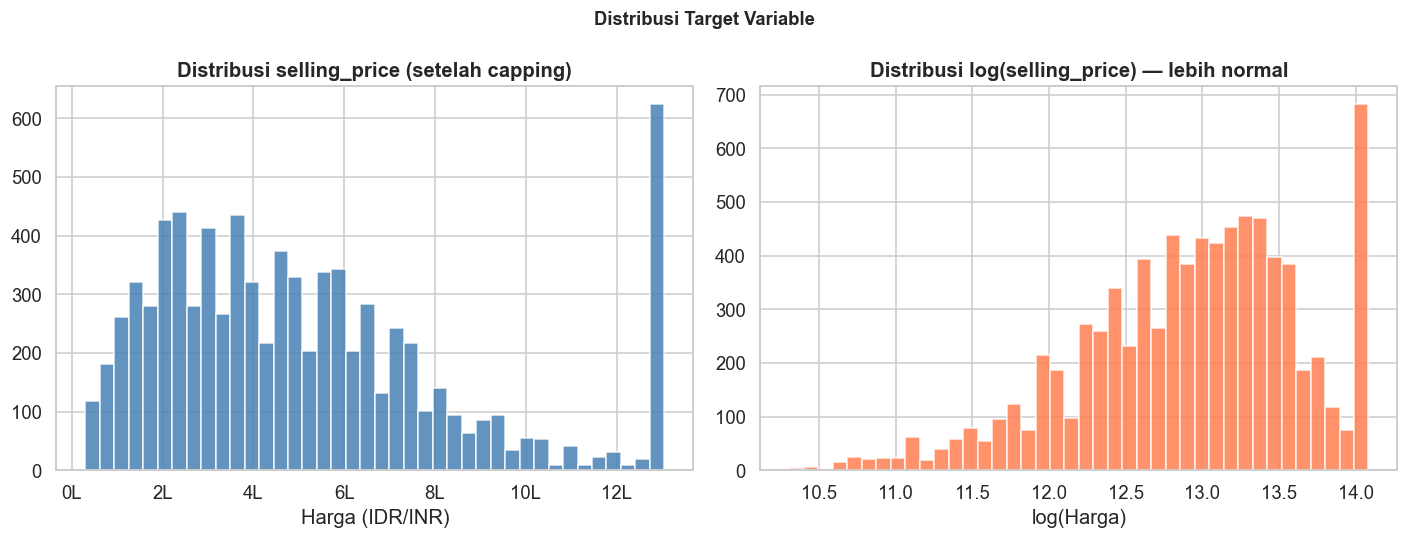


💡 Tip: Pertimbangkan log-transformasi target saat pelatihan model regresi!


In [69]:
# ── 8.4 Distribusi Target (selling_price) ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(y, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribusi selling_price (setelah capping)', fontweight='bold')
axes[0].set_xlabel('Harga (IDR/INR)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e5:.0f}L'))

axes[1].hist(np.log1p(y), bins=40, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribusi log(selling_price) — lebih normal', fontweight='bold')
axes[1].set_xlabel('log(Harga)')

plt.suptitle('Distribusi Target Variable', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💡 Tip: Pertimbangkan log-transformasi target saat pelatihan model regresi!')


>
> Dua histogram berdampingan menunjukkan:
> - **`selling_price` (asli setelah capping)**: masih right-skewed dengan mayoritas data di bawah ≈5 Lakh.
> - **`log(selling_price)`**: distribusi jauh lebih mendekati normal (bell-shaped).
>
> 💡 Transformasi log pada target variable direkomendasikan sebelum melatih model regresi linear — teknik yang dibahas dalam Sarkar et al. (2018) untuk menangani target yang tidak berdistribusi normal.